<a href="https://colab.research.google.com/github/thesuravaram/Machine-Learning/blob/main/Crop%20Recommendation%20With%20Meds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# We will test 3 common and powerful classifiers
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [35]:
# --- 1. Load and Clean Data ---
# The file has a complex name and some unnamed columns
file_path = "/Crop_Recm_Data.csv"

df = pd.read_csv(file_path)

initial_rows = len(df)
df = df.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)
rows_after_dropping = len(df)

print(f"[INFO] Removed {initial_rows - rows_after_dropping} duplicate rows.")
print(f"[SUCCESS] Dataset now has {rows_after_dropping} unique rows.")

print("\n--- 1. Initial Data Info ---")
df.info()


print("\n--- Cleaned Data Info ---")
print(df.info())
print(f"\n[SUCCESS] Data loaded and cleaned. {len(df)} rows remaining.")


[INFO] Removed 0 duplicate rows.
[SUCCESS] Dataset now has 10470 unique rows.

--- 1. Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10470 entries, 0 to 10469
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   N             10470 non-null  float64
 1   P             10470 non-null  float64
 2   K             10470 non-null  float64
 3   temperature   10470 non-null  float64
 4   humidity      10470 non-null  float64
 5   ph            10470 non-null  float64
 6   rainfall      10470 non-null  float64
 7   label         10470 non-null  object 
 8   Medicine      10470 non-null  object 
 9   Medicine_Use  10470 non-null  object 
dtypes: float64(7), object(3)
memory usage: 818.1+ KB

--- Cleaned Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10470 entries, 0 to 10469
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        -------------- 

In [36]:
# --- 2. Build Medicine Recommender (Lookup Table) ---
# This part does not require ML. We just create a dictionary.
print("\n--- 2. Building Medicine Recommender ---")
medicine_df = df[['label', 'Medicine', 'Medicine_Use']].drop_duplicates().reset_index(drop=True)

# Create the lookup dictionaries
medicine_lookup = medicine_df.set_index('label')['Medicine'].to_dict()
medicine_use_lookup = medicine_df.set_index('label')['Medicine_Use'].to_dict()

# Save the lookups
joblib.dump(medicine_lookup, 'medicine_lookup.joblib')
joblib.dump(medicine_use_lookup, 'medicine_use_lookup.joblib')
print("[SUCCESS] Medicine lookups created and saved.")
print("  - medicine_lookup.joblib")
print("  - medicine_use_lookup.joblib")


--- 2. Building Medicine Recommender ---
[SUCCESS] Medicine lookups created and saved.
  - medicine_lookup.joblib
  - medicine_use_lookup.joblib


In [37]:
test_size = 0.2

In [38]:
# --- 3. Prepare Data for ML (Crop Model) ---
print("\n--- 3. Preparing Data for Machine Learning ---")

# Define our features (X) and our target (y)
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'] # Added 'N' back
target = 'label'

X = df[features]
y = df[target]

# Encode the target variable (y) from text to numbers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
joblib.dump(encoder, 'crop_label_encoder.joblib')
print("[INFO] Target 'label' encoded and 'crop_label_encoder.joblib' saved.")

# Split the data into training and testing sets (using the defined test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2, # Use the variable here
    random_state=42,
    stratify=y_encoded # Ensures all crops are represented
)

# Scale the features (X)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'crop_scaler.joblib')
print("[INFO] Features scaled and 'crop_scaler.joblib' saved.")
print(f"  - Training data shape: {X_train_scaled.shape}")
print(f"  - Testing data shape:  {X_test_scaled.shape}")


--- 3. Preparing Data for Machine Learning ---
[INFO] Target 'label' encoded and 'crop_label_encoder.joblib' saved.
[INFO] Features scaled and 'crop_scaler.joblib' saved.
  - Training data shape: (8376, 7)
  - Testing data shape:  (2094, 7)


In [39]:
# --- 4. Train and Evaluate All Models ---
print("\n--- 4. Training and Comparing All Models ---")

# We will test 3 common and powerful classifiers
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []
best_model = None
best_accuracy = 0.0
best_model_name = ""

for name, model in models.items():
    print(f"  Training {name}...")
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Test the model
    y_pred = model.predict(X_test_scaled)

    # Calculate accuracy and error
    accuracy = accuracy_score(y_test, y_pred)
    error_rate = 1.0 - accuracy

    results.append({
        "Model": name,
        "Accuracy": accuracy, # Store as float for sorting
        "Error Rate": error_rate
    })


    # Check if this is the best model so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name

print("\n[SUCCESS] All models trained and evaluated.")


--- 4. Training and Comparing All Models ---
  Training Decision Tree...
  Training Random Forest...
  Training Gradient Boosting...

[SUCCESS] All models trained and evaluated.


In [40]:
# --- 5. Detailed Report for Best Model ---
print("\n" + "="*50)
print(f"--- 6. Detailed Evaluation for All Models ---")
print("="*50)

# Get the actual crop names for the report
class_names = encoder.classes_

# Iterate through all models and print their classification reports
for name, model in models.items():
    print(f"\n--- Detailed Evaluation: {name} ---")
    # We need the predictions from each model
    y_pred = model.predict(X_test_scaled)

    # Calculate accuracy and error for the current model
    accuracy = accuracy_score(y_test, y_pred)
    error_rate = 1.0 - accuracy

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Error Rate: {error_rate:.4f}")

    print("\nClassification Report (Errors per Crop):")
    # This report shows precision, recall, and f1-score for each crop.
    print(classification_report(y_test, y_pred, target_names=class_names))

# Also print the summary for the best model again for clarity
print("\n" + "="*50)
print(f"--- Summary for Best Model: {best_model_name} ---")
print("="*50)
print(f"Accuracy: {best_accuracy:.4f}")
print(f"Error Rate: {(1.0 - best_accuracy):.4f}")
print("\nClassification Report (Errors per Crop):")
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=class_names))


--- 6. Detailed Evaluation for All Models ---

--- Detailed Evaluation: Decision Tree ---
Accuracy: 0.8066
Error Rate: 0.1934

Classification Report (Errors per Crop):
              precision    recall  f1-score   support

       apple       0.98      0.98      0.98        97
      banana       0.95      0.86      0.90       212
   blackgram       0.79      0.79      0.79        29
    chickpea       0.78      0.74      0.76       297
     coconut       0.77      0.68      0.72        63
      coffee       0.88      0.88      0.88       169
      cotton       0.81      0.81      0.81        26
      grapes       0.91      0.97      0.94       264
        jute       0.62      0.56      0.59        71
 kidneybeans       0.98      0.97      0.97        90
      lentil       0.78      0.71      0.74        41
       maize       0.56      0.55      0.55        64
       mango       0.84      0.79      0.81        58
   mothbeans       0.55      0.61      0.58        75
    mungbean       0

In [41]:
# --- 6. Model Comparison and Error Calculation ---
print("\n" + "="*50)
print(f"--- 5. Model Comparison Results at {test_size} Test Size ---") # Use the variable here
print("="*50)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(f"\nBest Model: {best_model_name} with {best_accuracy * 100:.2f}% Accuracy")


--- 5. Model Comparison Results at 0.2 Test Size ---
            Model  Accuracy  Error Rate
    Decision Tree  0.806590    0.193410
    Random Forest  0.878223    0.121777
Gradient Boosting  0.928844    0.071156

Best Model: Gradient Boosting with 92.88% Accuracy



--- 8. Comparison Charts for Best Model: Gradient Boosting ---


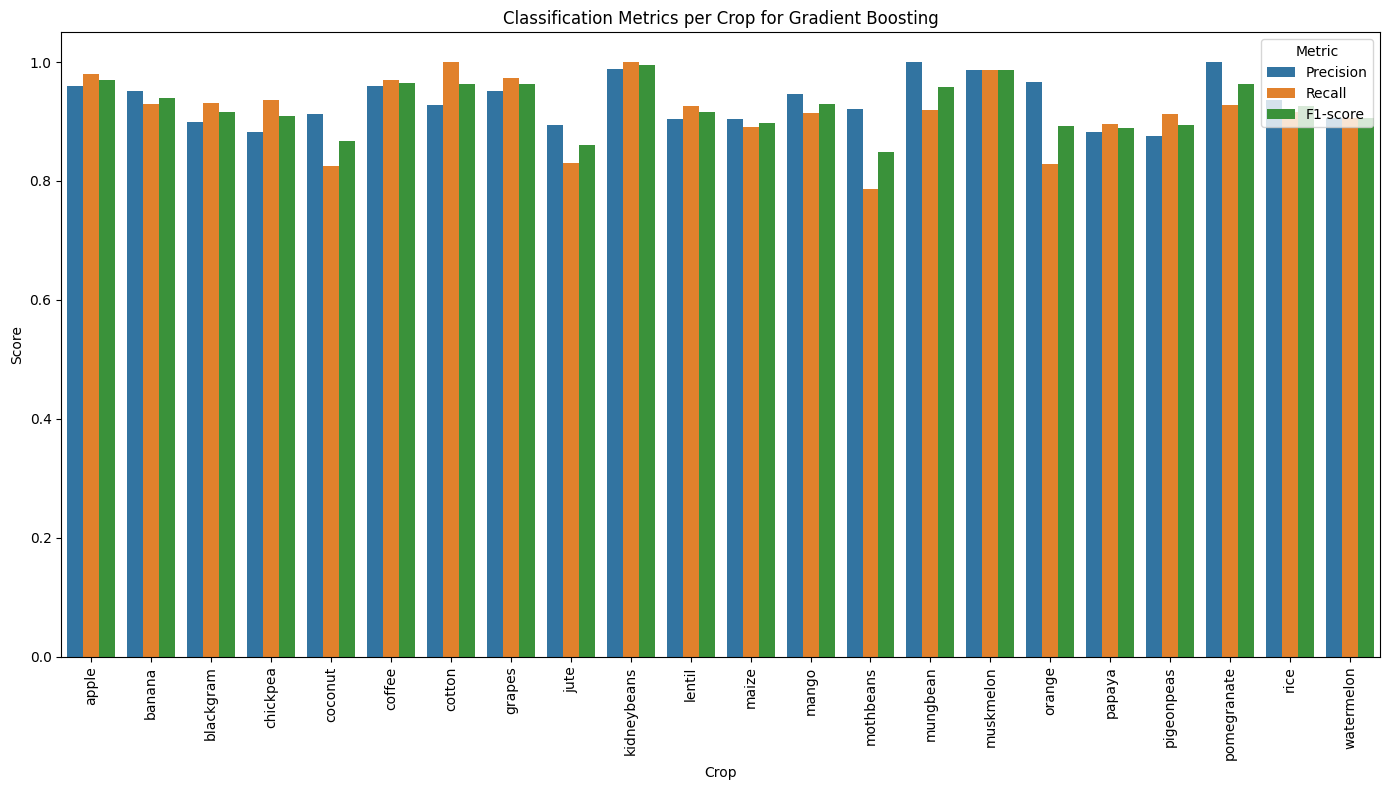


The chart above shows the Precision, Recall, and F1-score for each crop class


In [42]:
# --- 7. Comparison Charts for Best Model (Error Metrics) ---

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

print("\n" + "="*50)
print(f"--- 8. Comparison Charts for Best Model: {best_model_name} ---")
print("="*50)

# Get the classification report data for the best model
y_pred_best = best_model.predict(X_test_scaled)
precision, recall, f1_score, support = precision_recall_fscore_support(y_test, y_pred_best, average=None, labels=np.arange(len(class_names)))

# Create a DataFrame for plotting
metrics_df = pd.DataFrame({
    'Crop': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1_score
})

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt('Crop', var_name='Metric', value_name='Score')

# Create the bar plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Crop', y='Score', hue='Metric', data=metrics_melted)
plt.xticks(rotation=90)
plt.title(f'Classification Metrics per Crop for {best_model_name}')
plt.ylabel('Score')
plt.xlabel('Crop')
plt.tight_layout()
plt.show()

print("\nThe chart above shows the Precision, Recall, and F1-score for each crop class")


--- 9. Actual vs Predicted Chart for Gradient Boosting (Confusion Matrix) ---


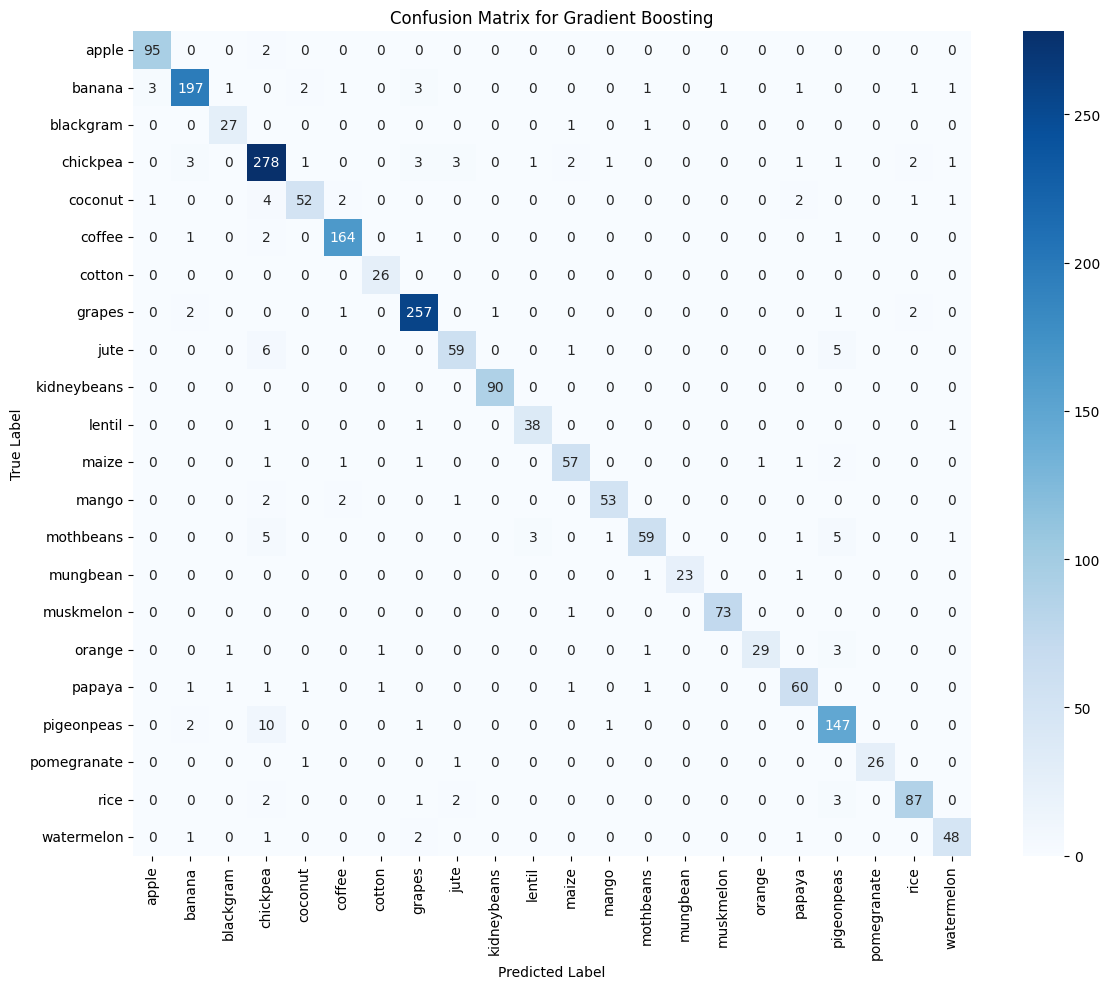


The chart above shows the confusion matrix for the best model (Gradient Boosting).
Each cell in the matrix represents the number of samples that were correctly or incorrectly classified.
The diagonal represents the number of samples that were correctly classified.
The off-diagonal represents the number of samples that were incorrectly classified.


In [43]:
# --- 8. Actual vs Predicted Chart for Gradient Boosting (Confusion Matrix) ---

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*50)
print(f"--- 9. Actual vs Predicted Chart for {best_model_name} (Confusion Matrix) ---")
print("="*50)

# Get predictions for the best model
y_pred_best = best_model.predict(X_test_scaled)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nThe chart above shows the confusion matrix for the best model ({best_model_name}).")
print("Each cell in the matrix represents the number of samples that were correctly or incorrectly classified.")
print("The diagonal represents the number of samples that were correctly classified.")
print("The off-diagonal represents the number of samples that were incorrectly classified.")


--- 10. Feature Importance Chart for Gradient Boosting ---


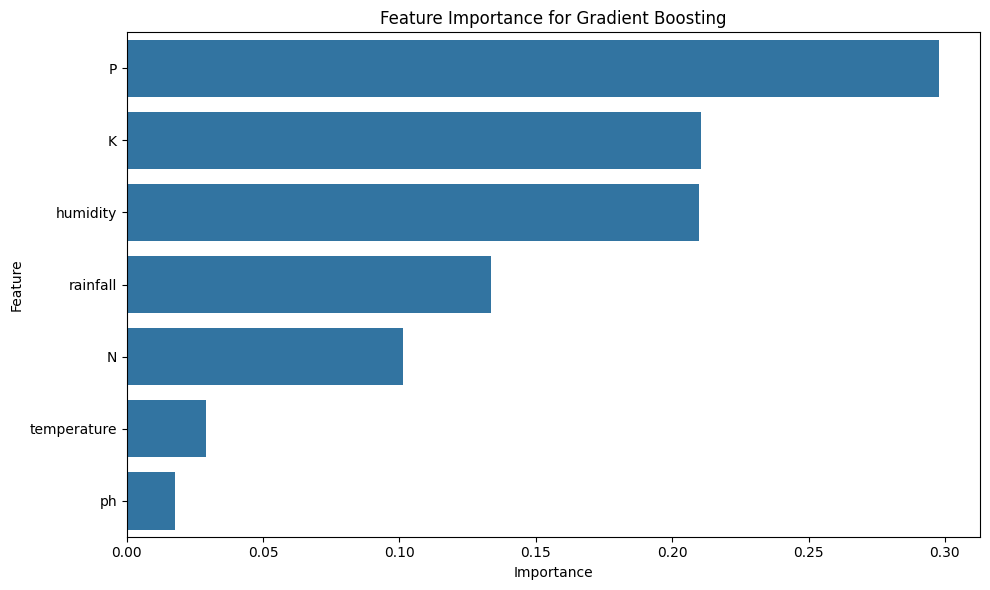


The chart above shows the importance of each feature in the best model (Gradient Boosting).
Features with higher importance contribute more to the model's predictions.


In [44]:
# --- 9. Feature Importance Chart for the Best Model ---

print("\n" + "="*50)
print(f"--- 10. Feature Importance Chart for {best_model_name} ---")
print("="*50)

# Get feature importances from the best model
# This is applicable for tree-based models like Decision Tree, Random Forest, and Gradient Boosting
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    features = X.columns # Get feature names from the original DataFrame

    # Create a DataFrame for plotting
    feature_importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})

    # Sort by importance
    feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
    plt.title(f'Feature Importance for {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    print(f"\nThe chart above shows the importance of each feature in the best model ({best_model_name}).")
    print("Features with higher importance contribute more to the model's predictions.")

else:
    print(f"[INFO] Feature importance is not available for the selected best model: {best_model_name}")